## ***Diabetes Dataset***

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Load your dataset
data = pd.read_csv("diabetes.csv")


In [ ]:
#data description
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


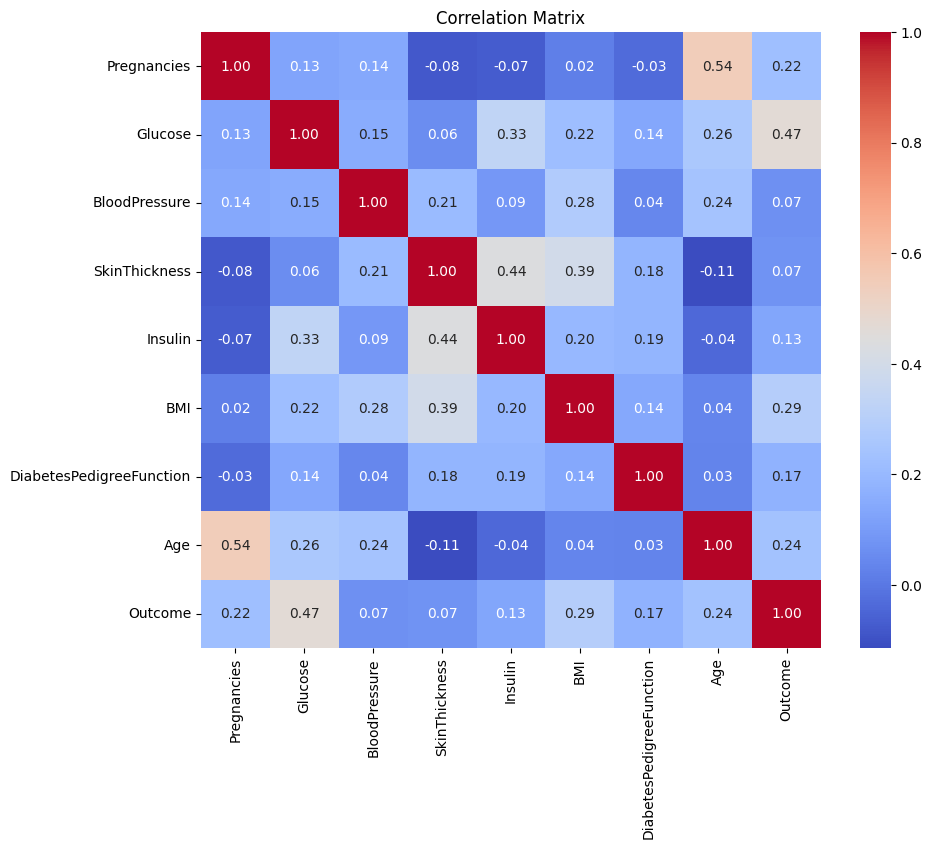

In [ ]:
#correlation metrix
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


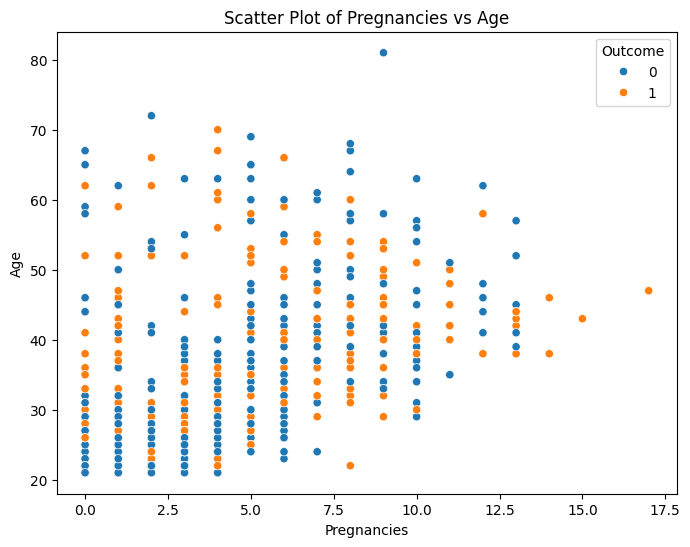

In [ ]:
#scatter plot for this dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Pregnancies', y='Age', hue='Outcome', data=data)
plt.title("Scatter Plot of Pregnancies vs Age")
plt.xlabel("Pregnancies")
plt.ylabel("Age")
plt.show()

In [ ]:
#seperate values of x and y
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [ ]:
#printing x and y
print(X)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Test different k values
accuracy_scores = []
train_accuracy_scores = []
k_values = range(1, 21)
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  y_train_pred = knn.predict(X_train)
  accuracy_scores.append(accuracy_score(y_test, y_pred))
  train_accuracy_scores.append(accuracy_score(y_train, y_train_pred))

In [ ]:
#number of features participating
num_features = X.shape[1]
print(f"The number of features participating in the model is: {num_features}")

The number of features participating in the model is: 8


In [ ]:
#table for printing both different k values with train accuracy and test accuracy
table_data = list(zip(k_values, train_accuracy_scores, accuracy_scores))
table = pd.DataFrame(table_data, columns=["k", "Train Accuracy", "Test Accuracy"])
print(table)


     k  Train Accuracy  Test Accuracy
0    1        1.000000       0.662338
1    2        0.843648       0.714286
2    3        0.856678       0.694805
3    4        0.817590       0.727273
4    5        0.804560       0.668831
5    6        0.789902       0.714286
6    7        0.781759       0.675325
7    8        0.786645       0.707792
8    9        0.794788       0.688312
9   10        0.783388       0.681818
10  11        0.791531       0.675325
11  12        0.776873       0.701299
12  13        0.781759       0.707792
13  14        0.781759       0.707792
14  15        0.778502       0.701299
15  16        0.781759       0.707792
16  17        0.775244       0.720779
17  18        0.785016       0.707792
18  19        0.786645       0.727273
19  20        0.783388       0.714286


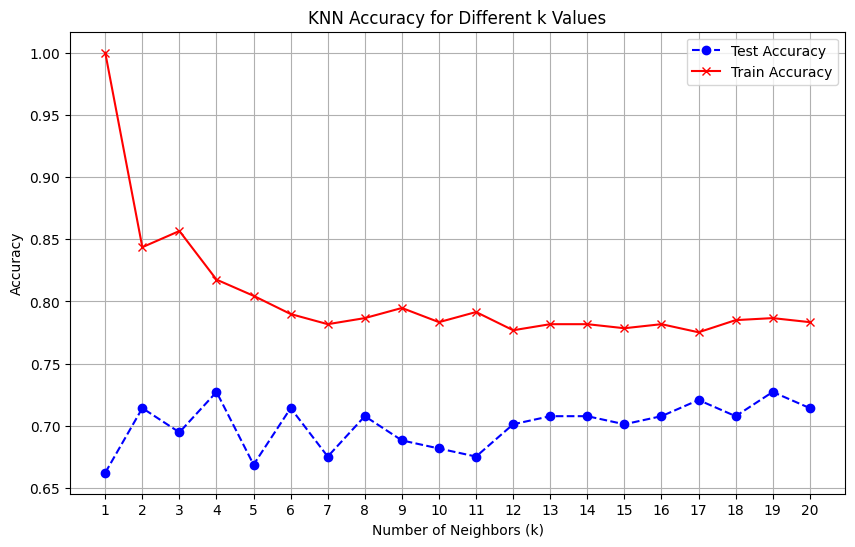

In [ ]:
# Plot accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='--', color='b', label='Test Accuracy')
plt.plot(k_values, train_accuracy_scores, marker='x', linestyle='-', color='r', label='Train Accuracy')
plt.title("KNN Accuracy for Different k Values")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
optimal_k_index = np.argmax(accuracy_scores)
optimal_k = k_values[optimal_k_index]
print(f"The optimal k value is: {optimal_k}")

The optimal k value is: 12


In [ ]:
# Train the final KNN model with the optimal k
final_knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=12)

In [ ]:
# Make predictions on the test set
y_pred_final = final_knn_model.predict(X_test)

In [ ]:
#accuracy of this
accuracy = accuracy_score(y_test, y_pred_final)
print(f"Accuracy of the final KNN model with k={optimal_k}: {accuracy:.4f}")

Accuracy of the final KNN model with k=12: 0.7727


In [ ]:
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_final)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[88 12]
 [23 31]]


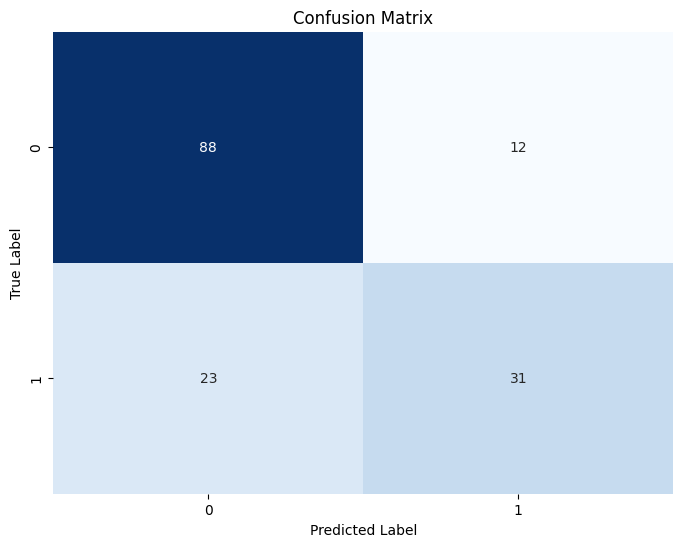

In [ ]:
#visualization of confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

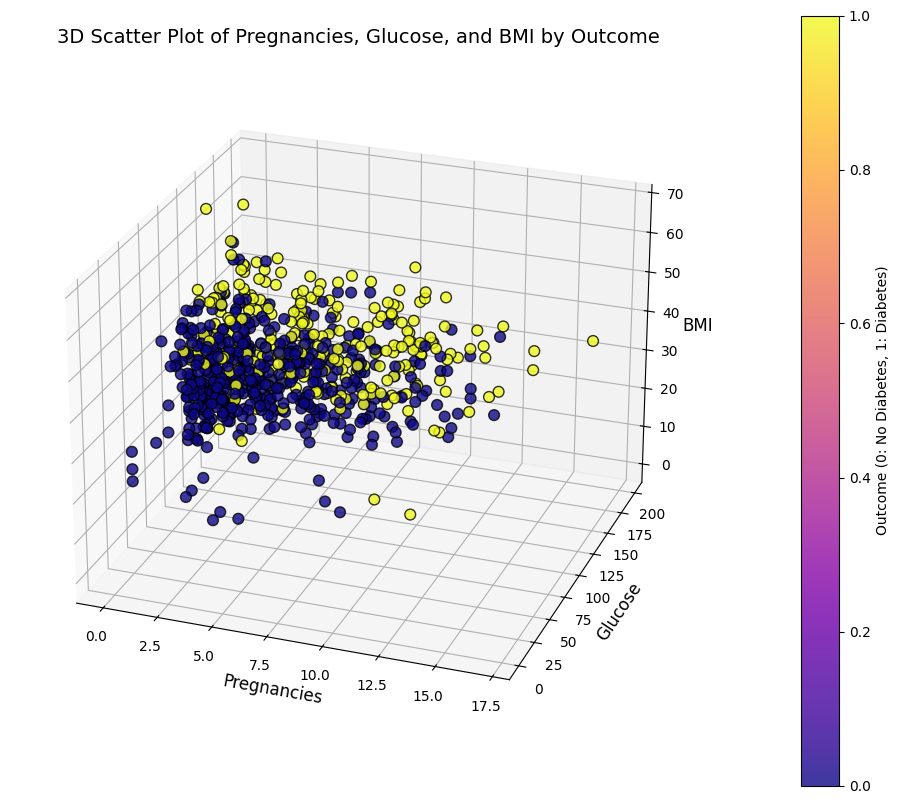

In [ ]:
# plotting this in 3d format for knn
plt.figure(figsize=(12, 10))
ax = plt.axes(projection='3d')

# Scatter plot with data for x, y, z axes and coloring by 'Outcome'
scatter = ax.scatter3D(data['Pregnancies'], data['Glucose'], data['BMI'],
                       c=data['Outcome'], cmap='plasma', s=60, alpha=0.8, edgecolor='black')

# Set labels and title
ax.set_xlabel('Pregnancies', fontsize=12)
ax.set_ylabel('Glucose', fontsize=12)
ax.set_zlabel('BMI', fontsize=12)
ax.set_title('3D Scatter Plot of Pregnancies, Glucose, and BMI by Outcome', fontsize=14)

# Add grid for better orientation
ax.grid(True)

# Set a specific viewing angle for better perception
ax.view_init(elev=25, azim=-70)

# Add a color bar for the 'Outcome' variable
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Outcome (0: No Diabetes, 1: Diabetes)', fontsize=10)

plt.show()